# Idea
this is a follow up on trend_forecast2.ipynb

## Data
I want to load the "interesting" subsets I have found:
- based on Flags of Events (Shock- Magnetic Obstacles)
- mased on orbital decay over 1 orbital period of GRACE-FO-1
and merge them into one dataset

## Forecasting Model

I want a forecasting model including
- ('orbital_decay')
- '|avg B|'
- 'F10.7 (LASP)'
- 'Bz GSE'
- 'Flow Speed (km/s'
- 'Temperature (K)'

but I want to test different models
- LinearRegression()
- Lasso()

to see the impact of regularisation

# Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.data_loader import find_repo_root
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import MultiTaskLasso
from sklearn.metrics import r2_score
from datetime import datetime
from sklearn.preprocessing import StandardScaler

# Settings

In [2]:
sampling_rate = '5min'
columns_needed = ['time', 'orbital_decay', 'trend','|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)', 'Kp (LASP)', 'median_decay_last_7D', 'median_decay_last_14D', 'median_decay_last_30D']
train_start_time = '2023-01-01 00:00:00'
train_end_time = '2023-07-01 00:00:00'
test_start_time = '2023-07-24 00:00:00'
test_end_time = '2024-01-01 00:00:00'
target = 'trend'
# ---- forecast parameters ----
n = 12  # hours ahead
m = 15  # minutes steps
# ---- Train only on subset ----
Subset = True  # if True, train only on interesting subsets
if Subset:
    invert = False  # if True, train on the uninteresting times
    Subset_DIR = find_repo_root() / Path("Analysis/Subsets")
    Subset_name = 'subsets_Kp.csv'  # 'subsets_Kp.csv'  # 'subsets_eflag.csv'  # 'subsets_meanstd.csv' # 'subsets_merged.csv'
    Subset_file = Subset_DIR / Path(Subset_name)

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns_needed)
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

# filter by time range
train_data = GFOC_data.loc[train_start_time:train_end_time]
test_data = GFOC_data.loc[test_start_time:test_end_time]
print(f"✅ Successfully filtered train data with shape: {train_data.shape} and test data with shape: {test_data.shape}")

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X = pd.read_parquet(X_file)
X_train = X.loc[train_start_time:train_end_time]
X_test = X.loc[test_start_time:test_end_time]
print(f"✅ Successfully loaded features X_train with shape: {X_train.shape} and X_test with shape: {X_test.shape}")
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y = pd.read_parquet(y_file)
y_train = y.loc[train_start_time:train_end_time]
y_test = y.loc[test_start_time:test_end_time]
print(f"✅ Successfully loaded target y_train with shape: {y_train.shape} and y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (210528, 11)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)', 'Kp (LASP)', 'median_decay_last_7D', 'median_decay_last_14D', 'median_decay_last_30D']
Sample rate: 5min
✅ Successfully filtered train data with shape: (52129, 11) and test data with shape: (46369, 11)
✅ Successfully loaded features X_train with shape: (51535, 538) and X_test with shape: (46369, 538)
✅ Successfully loaded target y_train with shape: (51535, 48) and y_test with shape: (46369, 48)


# Select subset data and Scale

In [4]:
if Subset:
    intervals_df = pd.read_csv(Subset_file)
    df = GFOC_data.copy()
    mask = pd.Series(False, index=df.index)

    for _, row in intervals_df.iterrows():
        mask |= (df.index >= row["start"]) & (df.index <= row["end"])
    
    if invert:
        mask = ~mask

    # Train only on these times
    active_times = GFOC_data[mask].index.intersection(X_train.index)
    print(f"Training on {len(active_times)} samples of total {X_train.shape[0]} samples")
    X_train = X_train.loc[active_times]
    y_train = y_train.loc[active_times]
    # Test only on these times
    active_test = GFOC_data[mask].index.intersection(X_test.index)
    print(f"Testing on {len(active_test)} samples of total {X_test.shape[0]} samples")
    X_test = X_test.loc[active_test]
    y_test = y_test.loc[active_test]
else:
    # Train on all times
    print(f"Using all training samples: {X_train.shape[0]}")

print(f"Final training data shape: X_train: {X_train.shape}")
# --- IGNORE ---
# this scaling is not correct for time series CV
# All feature scaling was performed within each training fold using statistics computed exclusively from past observations, preventing temporal information leakage.
# --------------
# scaler = StandardScaler()
# # scale and convert back to DataFrames
# X_train_scaled = pd.DataFrame(
#     scaler.fit_transform(X_train),
#     index=X_train.index,
#     columns=X_train.columns
# )
# print(f"Final scaled training data shape: X_train_scaled: {X_train_scaled.shape}")

# X_test_scaled = pd.DataFrame(
#     scaler.transform(X_test),
#     index=X_test.index,
#     columns=X_test.columns
# )

Training on 9936 samples of total 51535 samples
Testing on 9900 samples of total 46369 samples
Final training data shape: X_train: (9936, 538)


# Set up Training

In [5]:
def tscv_evaluate(X, Y, X_test, Y_test, alpha, tscv):
    train_scores = []
    val_scores = []
    log_start_time = datetime.now()

    for i, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
        print(f"\nStart with {i}th training")
        start_time = datetime.now()

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        Y_train, Y_val = Y.iloc[train_idx], Y.iloc[val_idx]
        print(f"X_train time: {X_train.index[0]} to {X_train.index[-1]}")
        print(f"X_val time: {X_val.index[0]} to {X_val.index[-1]}")

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("lasso", MultiTaskLasso(
                alpha=alpha,
                max_iter=20000,
                warm_start=True,
                selection="random"
            ))
        ])

        model.fit(X_train, Y_train)

        train_scores.append(
            r2_score(Y_train, model.predict(X_train))
        )
        val_scores.append(
            r2_score(Y_val, model.predict(X_val))
        )

        print(f"Finished after {datetime.now() - start_time}")

    # Refit once on all training data
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", MultiTaskLasso(
            alpha=alpha,
            max_iter=20000,
            warm_start=True,
            selection="random"
        ))
    ])
    print("\nStart with final training")
    start_time = datetime.now()
    final_model.fit(X, Y)
    print(f"Finished after {datetime.now() - start_time}")

    test_score = r2_score(Y_test, final_model.predict(X_test))

    print(f"Total run time: {datetime.now()-log_start_time}")

    return {
        "train_mean": np.mean(train_scores),
        "val_mean": np.mean(val_scores),
        "test": test_score
    }


## Train Models

In [ ]:
alpha_weak = 0.02    # near Model 3 optimum
alpha_strong = 0.2 # strong regularization

tscv_weak = TimeSeriesSplit(
    n_splits=3,
    test_size=None  # expanding window
)

tscv_strong = TimeSeriesSplit(
    n_splits=5,
    test_size=None  # expanding window
)

results_weak = tscv_evaluate(
    X_train, y_train,
    X_test, y_test,
    alpha=alpha_weak,
    tscv=tscv_weak
)

results_strong = tscv_evaluate(
    X_train, y_train,
    X_test, y_test,
    alpha=alpha_strong,
    tscv=tscv_strong
)


Start with 1th training
X_train time: 2023-01-14 21:00:00 to 2023-03-01 02:55:00
X_val time: 2023-03-14 03:00:00 to 2023-04-23 08:55:00
Finished after 0:13:41.781054

Start with 2th training
X_train time: 2023-01-14 21:00:00 to 2023-04-23 08:55:00
X_val time: 2023-04-23 09:00:00 to 2023-05-19 02:55:00


# Results

Weak regularization results: [np.float64(0.940935226703442), np.float64(-1.3648294758182191), -0.05602153482724059]
Strong regularization results: [np.float64(0.8860199449996917), np.float64(0.05019462936026168), 0.0008524834958285321]


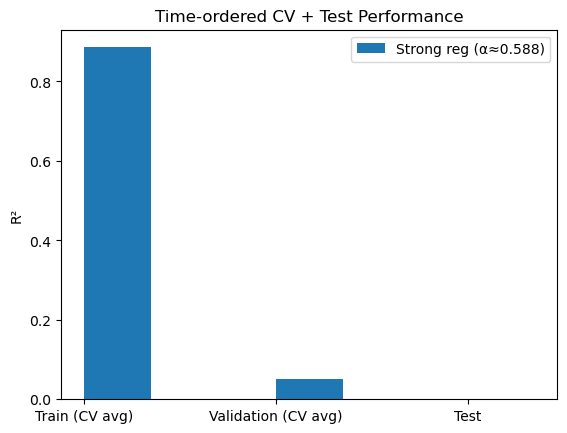

In [ ]:
labels = ["Train (CV avg)", "Validation (CV avg)", "Test"]

weak_scores = [
    results_weak["train_mean"],
    results_weak["val_mean"],
    results_weak["test"]
]
print("Weak regularization results:", weak_scores)

strong_scores = [
    results_strong["train_mean"],
    results_strong["val_mean"],
    results_strong["test"]
]
print("Strong regularization results:", strong_scores)

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, weak_scores, width, label=f"Weak reg (α={alpha_weak})")
plt.bar(x + width/2, strong_scores, width, label=f"Strong reg (α={alpha_strong})")

plt.xticks(x, labels)
plt.ylabel("R²")
plt.legend()
plt.title("Time-ordered CV + Test Performance")
plt.show()
